## EN 3160 - Image Processing and Machine Vision
### Assignment 01 -Intensity Transformations and Neighborhood Filtering

##### Name: K. D. Manatunga
##### Index Number: 230395T
##### Github: https://github.com/KaveeDiv23/Computer-Vision-Assignment-01

In [274]:
import numpy as np; import matplotlib.pyplot as plt; import cv2 as cv
plt.style.use("default")

#### Question 01

In [275]:
im1 = cv.imread("Images/emma.jpg",cv.IMREAD_GRAYSCALE)
breakpoints = np.array([
    [0, 0],[50, 50],[50, 100],[150, 255], [150, 150],[255, 255]
],dtype=np.float32)

In [276]:
def intensity_transform(im, bp):
    x = im.astype(np.float32); y = np.zeros_like(x)
    for i in range(0, len(bp) - 1, 2):
        x1, y1 = bp[i]; x2, y2 = bp[i + 1]
        if i == len(bp) - 2:
            mask = (x >= x1) & (x <= x2)
        else:
            mask = (x >= x1) & (x < x2)
        y[mask] = y1 + (y2 - y1) * (x[mask] - x1) / (x2 - x1)
    return np.clip(y, 0, 255).astype(np.uint8)

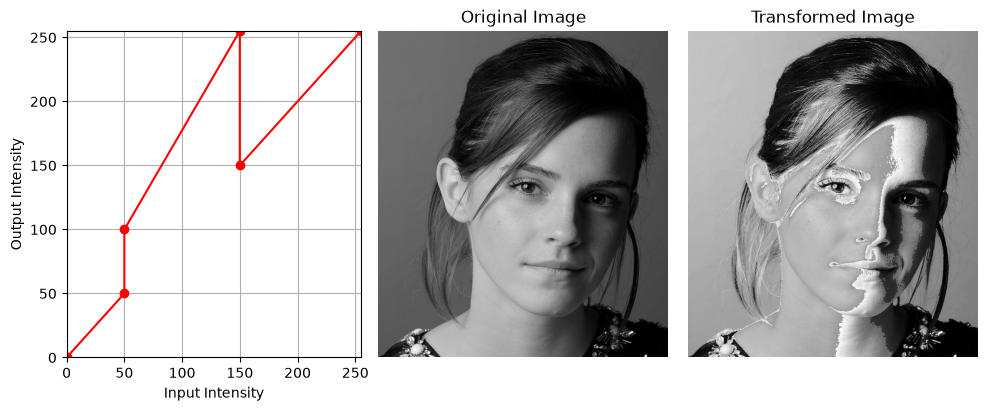

In [277]:
r1 = intensity_transform(im1, breakpoints)

plt.figure(figsize=(10, 4)); plt.subplot(1, 3, 1)
plt.plot(breakpoints[:, 0], breakpoints[:, 1], marker='o', color='red')
plt.xlabel("Input Intensity"); plt.ylabel("Output Intensity"); plt.xlim(0, 255)
plt.ylim(0, 255); plt.grid()
plt.subplot(1, 3, 2); plt.imshow(im1, cmap="gray"); plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(r1, cmap="gray"); plt.title("Transformed Image")
plt.axis("off"); plt.tight_layout(); plt.show()

**Interpretation** - The given linear transformation increases the intensity of the mid-intensity range pixels while the lowest and the highest intensity pixels remain unchanges. Also the discontinuities near intensities 50 and 150 creates high contrast regions in the output image

##### Experimenting Using different breakpoints.

In [278]:
def intensity_transform2(im, breakpoints):
    x = breakpoints[:, 0]; y = breakpoints[:, 1]
    result = np.interp(im, x, y)
    return np.clip(result, 0, 255).astype(np.uint8)

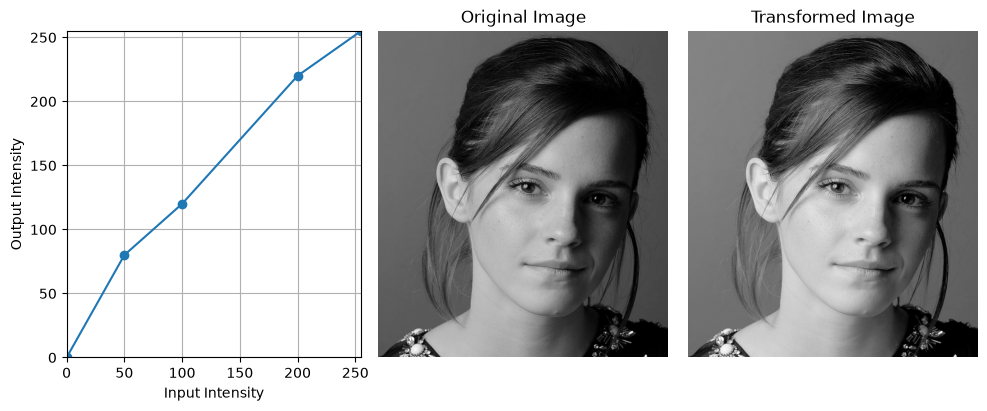

In [279]:
breakpoints2 = np.array([[0, 0], [50, 80], [100, 120],
                         [200, 220], [255, 255]], dtype=np.float32)
r2 = intensity_transform2(im1, breakpoints2)

plt.figure(figsize=(10, 4)); plt.subplot(1, 3, 1)
plt.plot(breakpoints2[:, 0], breakpoints2[:, 1], marker="o")
plt.xlabel("Input Intensity"); plt.ylabel("Output Intensity")
plt.xlim(0, 255); plt.ylim(0, 255); plt.grid()
plt.subplot(1, 3, 2); plt.imshow(im1, cmap="gray"); plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(r2, cmap="gray"); plt.title("Transformed Image")
plt.axis("off"); plt.tight_layout(); plt.show()

**Interpretation** - The breakpoints were adjusted to improve the visual appearance of the image. Also a separate linear transformation was used according to those breakpoints(One without discontinuities). This transformation increases darker and mid-range intensities while avoiding excessive clipping of high intensity regions. This improved the visibility of facial details and contrast while maintaining a more natural appearance

#### Question 2

In [280]:
brain = cv.imread("Images/Fig2.jpeg", cv.IMREAD_GRAYSCALE)
white_bp = np.array([[0, 0],[130, 20],[145, 50],[175, 190],
                     [205, 225],[255, 255]],dtype=np.float32)
gray_bp = np.array([[0, 0],[155, 20],[175, 50],[210, 200],
                    [235, 235],[255, 255]],dtype=np.float32)

In [281]:
white_result = intensity_transform2(brain, white_bp)
gray_result = intensity_transform2(brain, gray_bp)

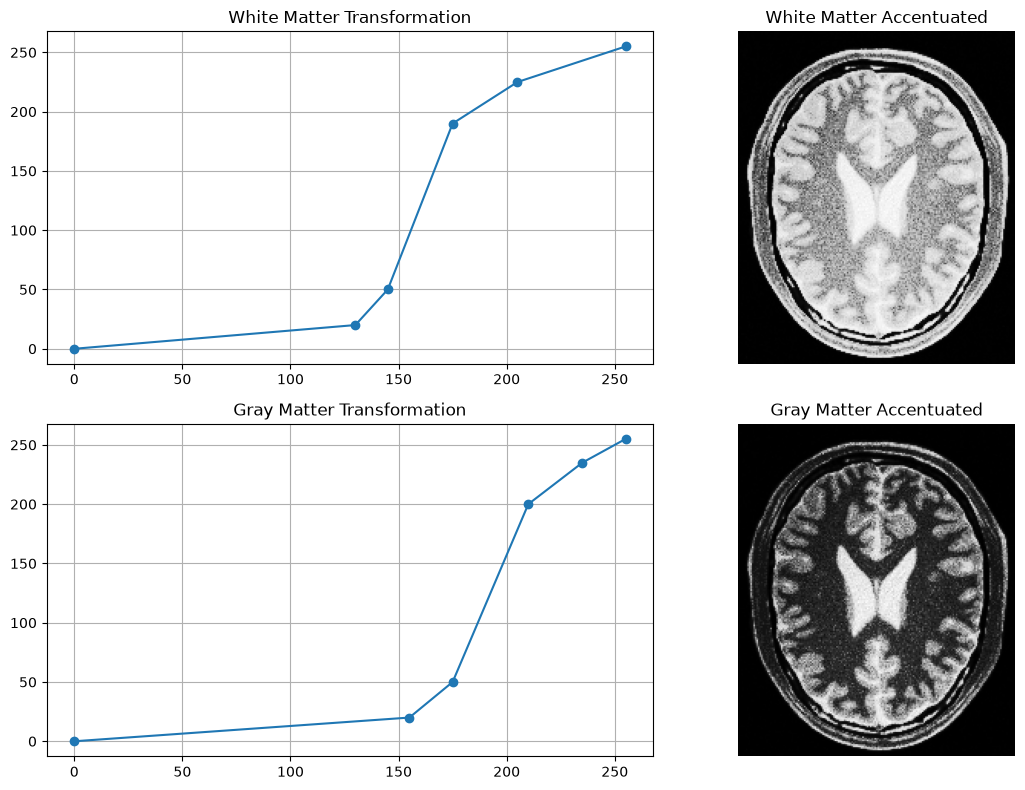

In [282]:
plt.figure(figsize=(12, 8)); plt.subplot(2, 2, 1)
plt.plot(white_bp[:, 0], white_bp[:, 1], marker="o")
plt.title("White Matter Transformation");plt.grid()
plt.subplot(2, 2, 2); plt.imshow(white_result, cmap="gray")
plt.title("White Matter Accentuated"); plt.axis("off")
plt.subplot(2, 2, 3); plt.plot(gray_bp[:, 0], gray_bp[:, 1], marker="o")
plt.title("Gray Matter Transformation"); plt.grid()
plt.subplot(2, 2, 4); plt.imshow(gray_result, cmap="gray")
plt.title("Gray Matter Accentuated"); plt.axis("off")
plt.tight_layout(); plt.show()

Separate linear transformations were used to expand intensity ranges corresponding to white and gray matter(Used the same function as the above and changed the breakpoints accordingly). Increased the slope within the corresponding tissue range inorder to increase the contrast between that surrounding regions.

#### Question 3

In [283]:
im3 = cv.imread("Images/Fig3.jpeg")
lab = cv.cvtColor(im3, cv.COLOR_BGR2LAB); L, a, b = cv.split(lab)
gamma = 0.7
L_norm = L.astype(np.float32) / 255.0; L_gamma = np.power(L_norm, gamma)
L_gamma = np.clip(L_gamma * 255, 0, 255).astype(np.uint8)
lab_gamma = cv.merge([L_gamma, a, b])
result_3 = cv.cvtColor(lab_gamma, cv.COLOR_LAB2RGB)
im3_rgb = cv.cvtColor(im3, cv.COLOR_BGR2RGB)

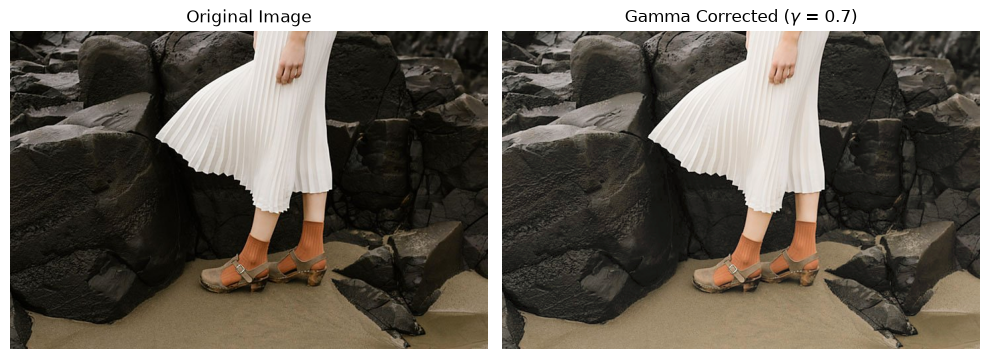

In [284]:
plt.figure(figsize=(10, 4)); plt.subplot(1, 2, 1)
plt.imshow(im3_rgb); plt.title("Original Image"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(result_3)
plt.title(f"Gamma Corrected ($\\gamma$ = {gamma})"); plt.axis("off")
plt.tight_layout(); plt.show()

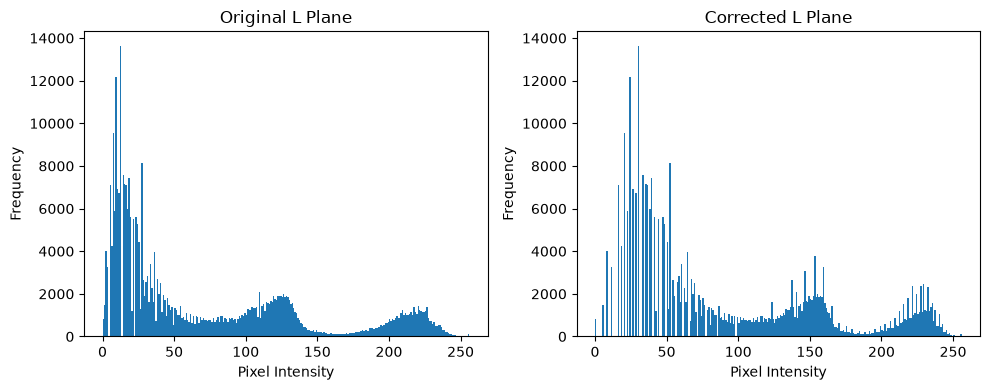

In [285]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1);plt.hist(L.ravel(),bins=256,range=(0, 256)); plt.title("Original L Plane")
plt.xlabel("Pixel Intensity"); plt.ylabel("Frequency")
plt.subplot(1, 2, 2); plt.hist(L_gamma.ravel(),bins=256,range=(0, 256))
plt.title("Corrected L Plane");plt.xlabel("Pixel Intensity"); plt.ylabel("Frequency")
plt.tight_layout(); plt.show()

**Interpretation** - Gamma correction was applied only to the L plane($\gamma = 0.7$). Since $\gamma<1$, darker pixels were shifted to higher intensities which made the shadow details more visible. Also the a and b planes were left unchanged inorder to preserve the color information. So the histogram of the corrected L plane is shifted towards higher intensities.

#### Question 4

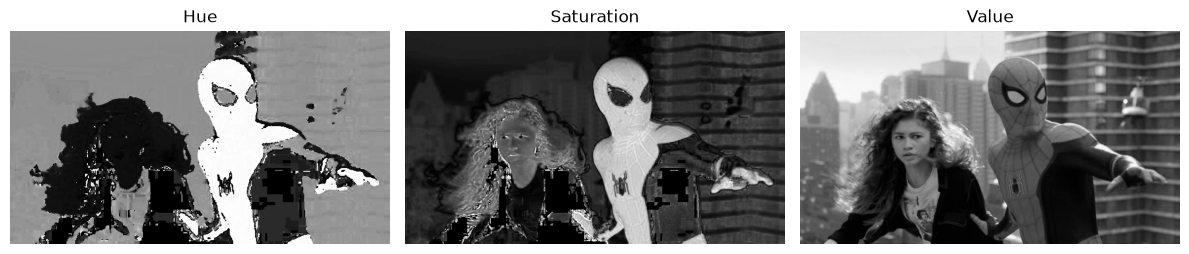

In [286]:
im4 = cv.imread("Images/Fig4.jpeg"); im4_rgb = cv.cvtColor(im4, cv.COLOR_BGR2RGB)
hsv = cv.cvtColor(im4, cv.COLOR_BGR2HSV); H, S, V = cv.split(hsv)

plt.figure(figsize=(12, 4)); plt.subplot(1, 3, 1); plt.imshow(H, cmap="gray")
plt.title("Hue"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(S, cmap="gray"); plt.title("Saturation")
plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(V, cmap="gray"); plt.title("Value")
plt.axis("off"); plt.tight_layout(); plt.show()

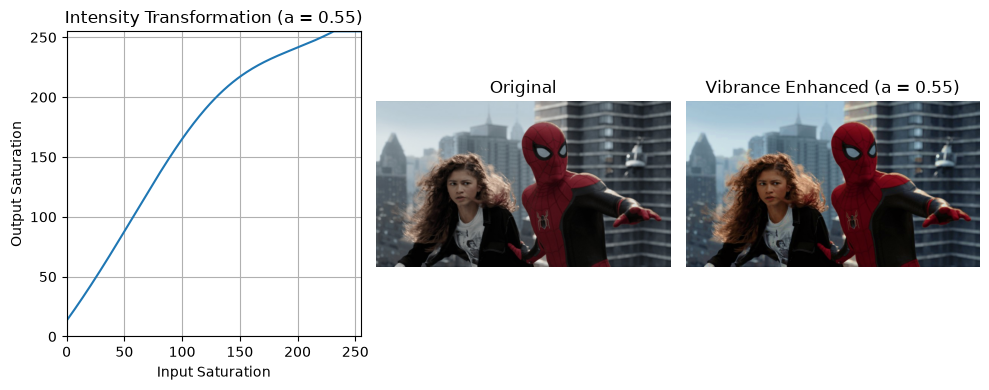

In [287]:
sigma = 70; a_val = 0.55
x = np.arange(256, dtype=np.float32)
f = x + a_val * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))
f = np.minimum(f, 255); f_uint8 = np.clip(f, 0, 255).astype(np.uint8)
S_enhanced = f_uint8[S]; hsv_enhanced = cv.merge([H, S_enhanced, V])
r4 = cv.cvtColor(hsv_enhanced, cv.COLOR_HSV2RGB)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1); plt.plot(x, f); plt.xlabel("Input Saturation")
plt.ylabel("Output Saturation"); plt.title(f"Intensity Transformation (a = {a_val})")
plt.xlim(0, 255); plt.ylim(0, 255); plt.grid()
plt.subplot(1, 3, 2); plt.imshow(im4_rgb); plt.title("Original"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(r4); plt.title(f"Vibrance Enhanced (a = {a_val})")
plt.axis("off"); plt.tight_layout(); plt.show()

a = 0.55

**Interpretation** - The transformation was applied to the saturation plane with a = 0.55. This increased the saturation of the moderately saturated pixels which made the colours appear more vivid. Since the hue and value planes remained unchanged, this enhancement mainly increased the vibrance of the image.

##### Question 05

In [288]:
def histogram_equalization(im):
    hist = np.bincount(im.ravel(), minlength = 256)
    cdf = np.cumsum(hist); nz = cdf[cdf > 0]; cdf_min =  nz[0]; total_p = im.size
    mapping = ((cdf - cdf_min) / (total_p - cdf_min) * 255)
    mapping = np.clip(mapping, 0, 255).astype(np.uint8); equalized = mapping[im]
    return equalized

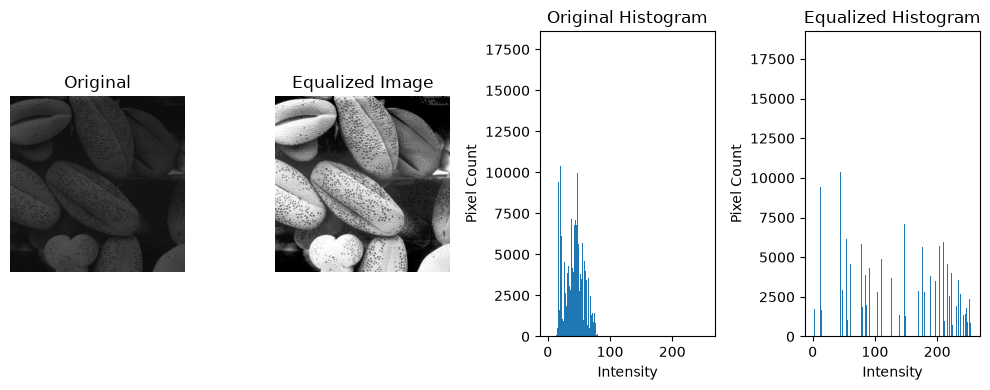

In [289]:
im5 = cv.imread("Images/shells.tif", cv.IMREAD_GRAYSCALE)
equalized_im = histogram_equalization(im5)

plt.figure(figsize=(10, 4))
plt.subplot(1, 4, 1); plt.imshow(im5, cmap="gray", vmin=0, vmax=255)
plt.title("Original"); plt.axis("off")
plt.subplot(1, 4, 2); plt.imshow(equalized_im, cmap="gray", vmin=0, vmax=255)
plt.title("Equalized Image"); plt.axis("off")
plt.subplot(1, 4, 3); plt.hist(im5.ravel(),bins=256,range=(0, 256))
plt.title("Original Histogram");plt.xlabel("Intensity");plt.ylabel("Pixel Count")
plt.subplot(1, 4, 4); plt.hist(equalized_im.ravel(),bins=256,range=(0, 256));
plt.title("Equalized Histogram"); plt.xlabel("Intensity");plt.ylabel("Pixel Count")
plt.tight_layout(); plt.show()

**Interpretation** - The histogram values are spread in a wider range of intensities after the histogram equalization. So the contrast of the image is increased and the details in the originally compressed intensity regions become much more visible.

#### Question 06

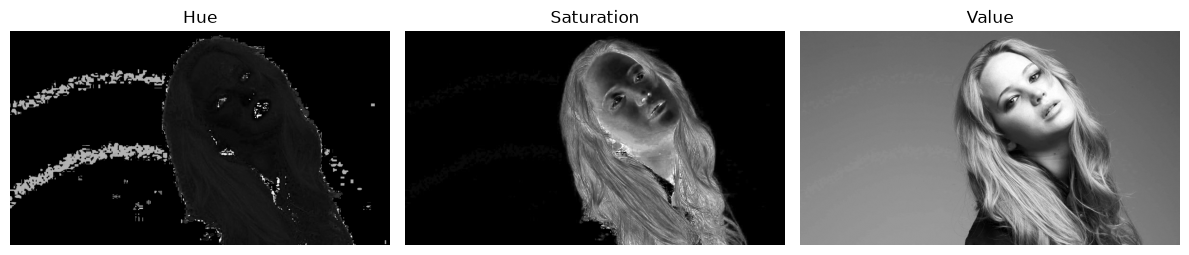

In [290]:
im6 = cv.imread("Images/Fig6.jpeg"); im6_rgb = cv.cvtColor(im6, cv.COLOR_BGR2RGB)
hsv_6 = cv.cvtColor(im6, cv.COLOR_BGR2HSV); H, S, V = cv.split(hsv_6)

plt.figure(figsize=(12, 4)); plt.subplot(1, 3, 1); plt.imshow(H, cmap="gray");
plt.title("Hue"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(S, cmap="gray"); plt.title("Saturation")
plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(V, cmap="gray"); plt.title("Value")
plt.axis("off"); plt.tight_layout(); plt.show()

In [291]:
_, mask6 = cv.threshold(S, 0, 255,cv.THRESH_BINARY + cv.THRESH_OTSU)
foreground = cv.bitwise_and(im6, im6, mask=mask6); fg_values = V[mask6 > 0]
hist_fg = np.bincount(fg_values, minlength=256)
cdf_fg = np.cumsum(hist_fg); cdf_min = cdf_fg[cdf_fg > 0][0]
total_fg = fg_values.size

mapping = ((cdf_fg - cdf_min) / (total_fg - cdf_min) * 255)
mapping = np.clip(mapping, 0, 255).astype(np.uint8)
V_equalized = V.copy()
V_equalized[mask6 > 0] = mapping[V[mask6 > 0]]
hsv_equalized = cv.merge([H, S, V_equalized])
equalized_bgr = cv.cvtColor(hsv_equalized, cv.COLOR_HSV2BGR)
equalized_foreground = cv.bitwise_and(equalized_bgr, equalized_bgr, mask=mask6)
background_mask = cv.bitwise_not(mask6)
background = cv.bitwise_and(im6, im6, mask=background_mask)
result6_bgr = cv.add(background, equalized_foreground)
result6_rgb = cv.cvtColor(result6_bgr, cv.COLOR_BGR2RGB)

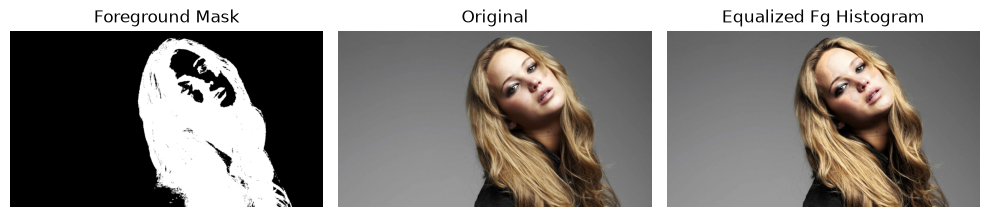

In [292]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1);plt.imshow(mask6, cmap="gray"); plt.title("Foreground Mask")
plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(im6_rgb); plt.title("Original"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(result6_rgb); plt.title("Equalized Fg Histogram")
plt.axis("off"); plt.tight_layout(); plt.show()

**Interpretation** - After the histogram equalization, foreground contrast was increased especially in the darker regions. This can be seen from the darkened shadows below the face. Since the transformation was applied only inside the mask, the background remained mostly unchanged.

#### Question 07

In [293]:
im7 = cv.imread("Images/Fig7.jpeg", cv.IMREAD_GRAYSCALE)
Gx = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float32)
Gy = Gx.T

**_Part (a)_**

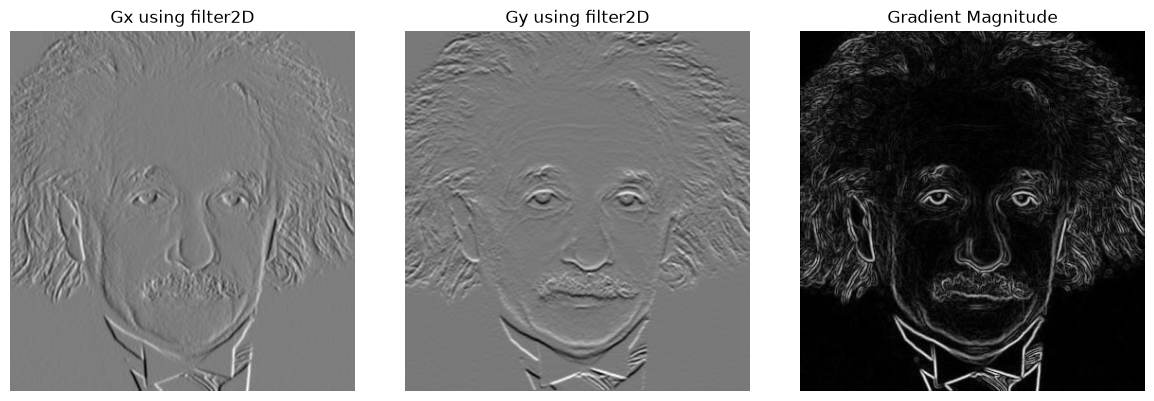

In [294]:
im7_float = im7.astype(np.float32)
gx = cv.filter2D(im7_float, cv.CV_32F, Gx)
gy = cv.filter2D(im7_float, cv.CV_32F, Gy)
mag = np.sqrt(gx ** 2 + gy ** 2)
mag_norm = cv.normalize(mag, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(12,4)); plt.subplot(1,3,1); plt.imshow(gx, cmap="gray")
plt.title("Gx using filter2D"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(gy, cmap="gray"); plt.title("Gy using filter2D")
plt.axis("off")
plt.subplot(1,3,3); plt.imshow(mag_norm, cmap="gray")
plt.title("Gradient Magnitude"); plt.axis("off")
plt.tight_layout(); plt.show()

**_Part (b)_**

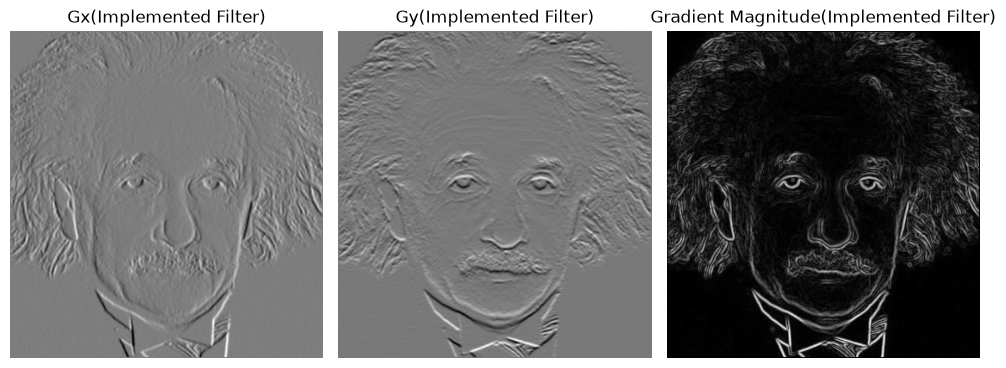

In [295]:
def my_filter(im, filter):
    out = np.zeros_like(im, dtype=np.float32)
    for i in range(1, im.shape[0] - 1):
        for j in range(1, im.shape[1] - 1):
            out[i, j] = np.sum(im[i-1:i+2, j-1:j+2] * filter)
    return out

gx2 = my_filter(im7_float, Gx); gy2 = my_filter(im7_float, Gy)
mag2 = np.sqrt(gx2**2 + gy2**2)
mag2_norm = cv.normalize(mag2, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(10,4)); plt.subplot(1,3,1); plt.imshow(gx2, cmap="gray")
plt.title("Gx(Implemented Filter)"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(gy2, cmap="gray")
plt.title("Gy(Implemented Filter)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(mag2_norm, cmap="gray")
plt.title("Gradient Magnitude(Implemented Filter)"); plt.axis("off")
plt.tight_layout(); plt.show()

**_Part (c):_**

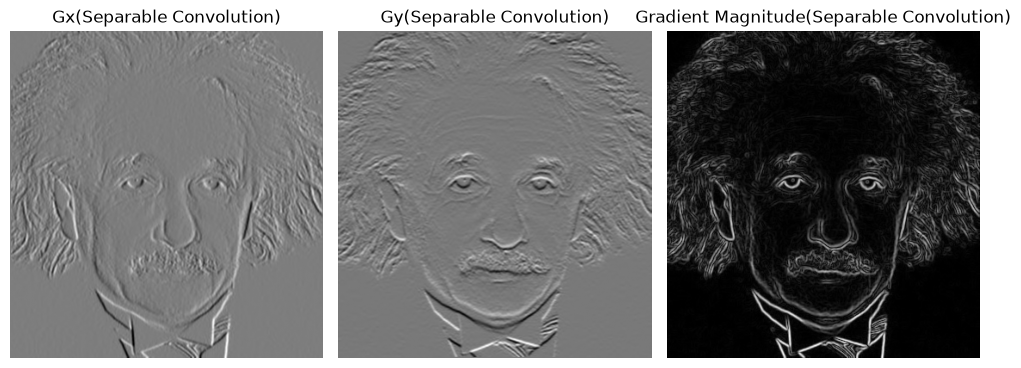

In [296]:
ver = np.array([1, 2, 1], dtype=np.float32)
hr = np.array([1, 0, -1], dtype=np.float32)
gx3 = cv.sepFilter2D(im7_float, cv.CV_32F, hr, ver)
gy3 = cv.sepFilter2D(im7_float, cv.CV_32F, ver, hr)
mag3 = np.sqrt(gx3**2 + gy3**2)
mag3_norm = cv.normalize(mag3, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(10,4)); plt.subplot(1,3,1); plt.imshow(gx3, cmap="gray")
plt.title("Gx(Separable Convolution)"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(gy3, cmap="gray")
plt.title("Gy(Separable Convolution)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(mag3_norm, cmap="gray")
plt.title("Gradient Magnitude(Separable Convolution)");plt.axis("off")
plt.tight_layout(); plt.show()

**Interpretation:** The three Sobel implementations produced similar edge patterns. $G_x$ mainly detected vertical edges, while $G_y$ mainly detected horizontal edges. The gradient magnitude combined both directions and showed the overall edges more clearly.

#### Question 8

In [297]:
def nearest_neighbour(im, s):
    h, w = im.shape[:2]; new_h = int(h * s); new_w = int(w * s)
    out = np.zeros((new_h, new_w, im.shape[2]), dtype=im.dtype)
    for y in range(new_h):
        for x in range(new_w):
            src_x = min(int(x / s), w - 1); src_y = min(int(y / s), h - 1)
            out[y, x] = im[src_y, src_x]
    return out

def bilinear_Interpol(im, s):
    h, w = im.shape[:2]; new_h = int(h * s); new_w = int(w * s)
    im_float = im.astype(np.float32)
    out = np.zeros((new_h, new_w, im.shape[2]), dtype=np.uint8)
    for y in range(new_h):
        for x in range(new_w):
            src_y = y / s; src_x = x / s
            y0 = int(np.floor(src_y)); x0 = int(np.floor(src_x))
            y1 = min(y0 + 1, h - 1); x1 = min(x0 + 1, w - 1)
            dy = src_y - y0; dx = src_x - x0
            value = ((1-dx)*(1-dy)*im_float[y0,x0] + dx*(1-dy)*im_float[y0, x1]
            + (1-dx)*dy*im_float[y1, x0] + dx*dy*im_float[y1, x1])
            out[y, x] = np.clip(value, 0, 255)
    return out

def ssd_norm(ref, test):
    ref = ref.astype(np.float64); test = test.astype(np.float64)
    return np.sum((ref - test) ** 2) / np.sum(ref ** 2)

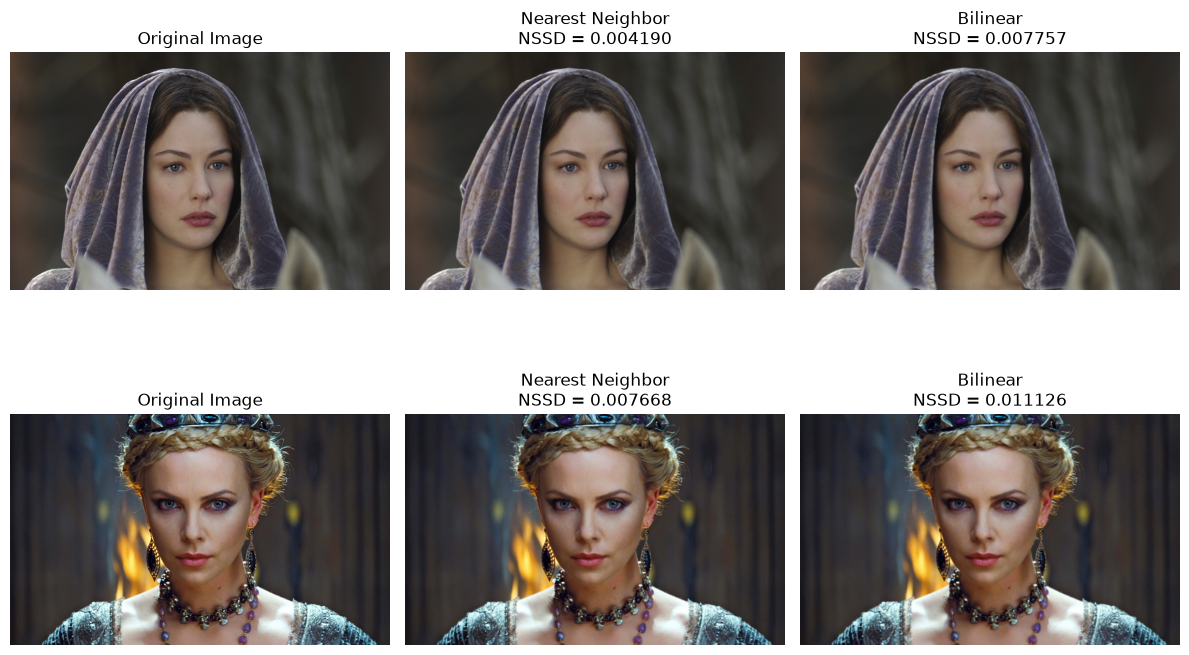

In [298]:
small1 = cv.imread("Images/Fig10_a_small.png")
large1 = cv.imread("Images/Fig10_a.png")
small2 = cv.imread("Images/Fig10_ct_small.png")
large2 = cv.imread("Images/Fig10_ct.png")

nn1 = nearest_neighbour(small1, 4); bi1 = bilinear_Interpol(small1, 4)
nn2 = nearest_neighbour(small2, 4); bi2 = bilinear_Interpol(small2, 4)
nn1 = nn1[:large1.shape[0],:large1.shape[1]]
bi1 = bi1[:large1.shape[0],:large1.shape[1]]
nn2 = nn2[:large2.shape[0], :large2.shape[1]]
bi2 = bi2[:large2.shape[0], :large2.shape[1]]
ssd_nn1 = ssd_norm(large1, nn1); ssd_bi1 = ssd_norm(large1, bi1)
ssd_nn2 = ssd_norm(large2, nn2); ssd_bi2 = ssd_norm(large2, bi2)
large1_rgb = cv.cvtColor(large1, cv.COLOR_BGR2RGB)
nn1_rgb = cv.cvtColor(nn1, cv.COLOR_BGR2RGB)
bi1_rgb = cv.cvtColor(bi1, cv.COLOR_BGR2RGB)
large2_rgb = cv.cvtColor(large2, cv.COLOR_BGR2RGB)
nn2_rgb = cv.cvtColor(nn2, cv.COLOR_BGR2RGB)
bi2_rgb = cv.cvtColor(bi2, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8)); plt.subplot(2, 3, 1); plt.imshow(large1_rgb)
plt.title("Original Image"); plt.axis("off")
plt.subplot(2, 3, 2); plt.imshow(nn1_rgb)
plt.title(f"Nearest Neighbor\nNSSD = {ssd_nn1:.6f}"); plt.axis("off")
plt.subplot(2, 3, 3); plt.imshow(bi1_rgb)
plt.title(f"Bilinear\nNSSD = {ssd_bi1:.6f}"); plt.axis("off")
plt.subplot(2, 3, 4); plt.imshow(large2_rgb); plt.title("Original Image")
plt.axis("off")
plt.subplot(2, 3, 5); plt.imshow(nn2_rgb)
plt.title(f"Nearest Neighbor\nNSSD = {ssd_nn2:.6f}"); plt.axis("off")
plt.subplot(2, 3, 6); plt.imshow(bi2_rgb)
plt.title(f"Bilinear\nNSSD = {ssd_bi2:.6f}"); plt.axis("off")
plt.tight_layout();plt.show()

**Interpretation** - The bilinear interpolation produces a smoother image because it uses the weighted average of 4 neighbouring pixels where in the nearest neighbour interpolation, the pixels are directly taken from the original. But in these images, nearest-neighbor interpolation produced the lower normalized SSD for both image pairs. This indicates that it matched the original images more closely, even though the bilinear results may appear visually smoother. This also shows that a smoother image does not always produce a lower SSD value.

#### Question 9

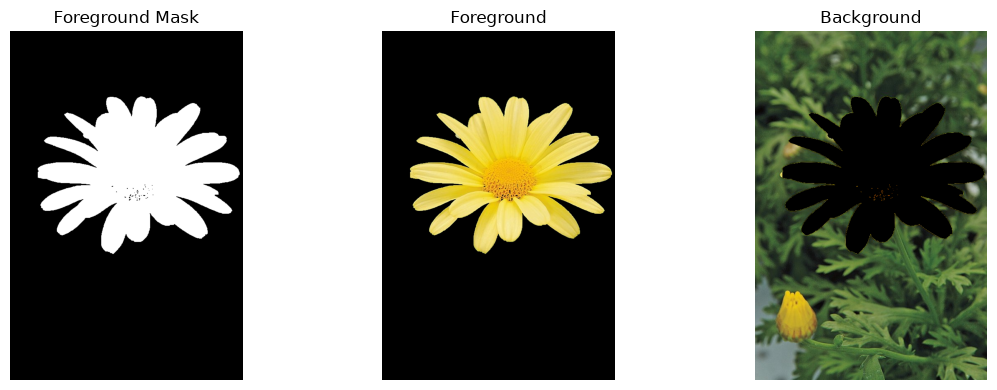

In [299]:
im9 = cv.imread("Images/Fig8_Flower.jpeg")
im9_rgb = cv.cvtColor(im9, cv.COLOR_BGR2RGB)
h, w = im9.shape[:2]; mask = np.zeros((h, w), np.uint8)
background_m = np.zeros((1, 65), np.float64)
foreground_m = np.zeros((1, 65), np.float64)
x1 = int(0.12 * w); y1 = int(0.08 * h); x2 = int(0.99 * w); y2 = int(0.70 * h)
rect = (x1, y1, x2-x1, y2-y1)
cv.grabCut( im9, mask, rect, background_m, foreground_m, 5, cv.GC_INIT_WITH_RECT)
mask_fg = np.where(
    (mask == cv.GC_FGD) | (mask == cv.GC_PR_FGD), 255, 0
).astype(np.uint8)
foreground = cv.bitwise_and(im9, im9, mask=mask_fg)
mask_bg = cv.bitwise_not(mask_fg); bg = cv.bitwise_and(im9, im9, mask=mask_bg)

plt.figure(figsize=(12, 4));plt.subplot(1, 3, 1); plt.imshow(mask_fg, cmap="gray")
plt.title("Foreground Mask"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
plt.title("Foreground"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(cv.cvtColor(bg, cv.COLOR_BGR2RGB))
plt.title("Background"); plt.axis("off")
plt.tight_layout(); plt.show()

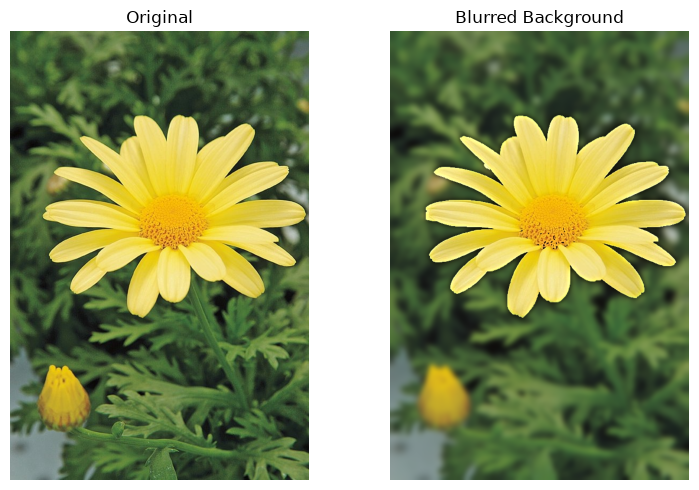

In [300]:
bg_blur = cv.GaussianBlur(bg, (31, 31), 0)
r9 = cv.add(foreground, bg_blur); r9_rgb = cv.cvtColor(r9, cv.COLOR_BGR2RGB)

plt.figure(figsize=(8, 5)); plt.subplot(1, 2, 1); plt.imshow(im9_rgb)
plt.title("Original"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(r9_rgb); plt.title("Blurred Background")
plt.axis("off"); plt.tight_layout(); plt.show()

**Reason for dark background just beyond the edge of the flower**
The dark edge is caused by blurring the masked background, where the removed foreground region contains black pixels. During Gaussian filtering, these zero valued(black) pixels are averaged with nearby background pixels. This produces a dark halo along the foreground boundary.

##### Question 10

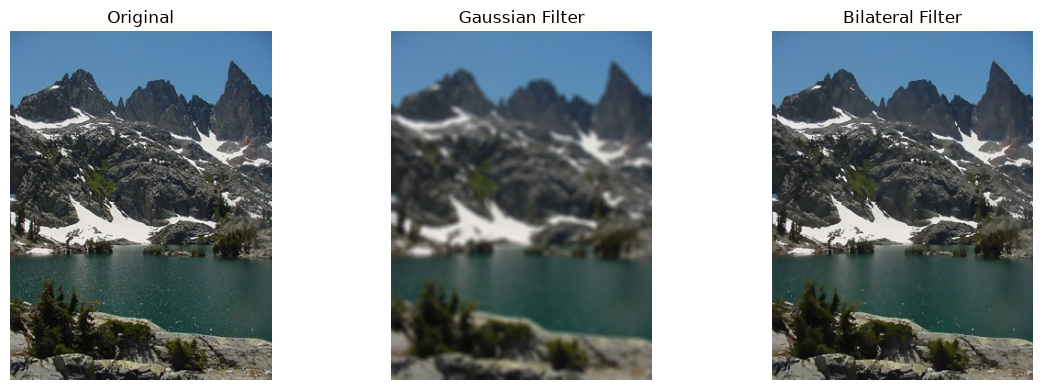

In [301]:
im10 = cv.imread("Images/Fig9.jpeg")
im10_rgb = cv.cvtColor(im10, cv.COLOR_BGR2RGB)
n, sigma_s, sigma_r = 7, 3, 50
bilateral_cv = cv.bilateralFilter( im10, n, sigma_r, sigma_s)
bilateral_cv_rgb = cv.cvtColor( bilateral_cv, cv.COLOR_BGR2RGB)
gaussian = cv.GaussianBlur(im10, (n, n), sigma_s)
gaussian_rgb = cv.cvtColor( gaussian, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 4)); plt.subplot(1, 3, 1); plt.imshow(im10_rgb)
plt.title("Original"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(gaussian_rgb)
plt.title("Gaussian Filter"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(bilateral_cv_rgb); plt.title("Bilateral Filter")
plt.axis("off"); plt.tight_layout(); plt.show()

In [302]:
def my_bilateralF(im, d, s_s, s_r):
    r = d // 2
    padded = cv.copyMakeBorder(im, r, r, r, r, cv.BORDER_REFLECT)
    out = np.zeros_like(im)
    for y in range(im.shape[0]):
        for x in range(im.shape[1]):
            center = padded[y+r, x+r].astype(np.float32)
            pixel_sum = np.zeros(3, dtype=np.float32)
            weight_sum = 0
            for j in range(-r, r+1):
                for i in range(-r, r+1):
                    neighbour = padded[y+r+j, x+r+i].astype(np.float32)
                    spatial = np.exp(-(i**2 + j**2) / (2 * s_s**2))
                    difference = np.sum((neighbour - center)**2)
                    intensity = np.exp(-difference / (2 * s_r**2))
                    weight = spatial * intensity
                    pixel_sum += weight * neighbour
                    weight_sum += weight
            out[y, x] = np.clip(pixel_sum / weight_sum, 0, 255)
    return out

MSE = 15.937996


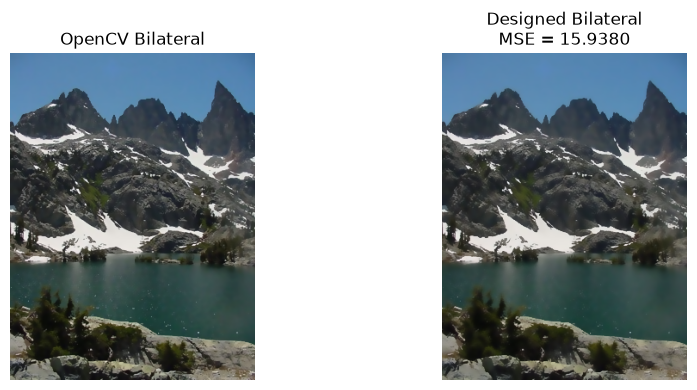

In [303]:
def mse(im1, im2):
    im1 = im1.astype(np.float32); im2 = im2.astype(np.float32)
    return np.mean((im1 - im2) ** 2)

bilateral_f = my_bilateralF(im10, n, sigma_s, sigma_r)
bilateral_f_rgb = cv.cvtColor(bilateral_f, cv.COLOR_BGR2RGB)
mse_v = mse(bilateral_cv, bilateral_f)
print("MSE =", mse_v)

plt.figure(figsize=(10, 4)); plt.subplot(1, 2, 1); plt.imshow(bilateral_cv_rgb)
plt.title("OpenCV Bilateral"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(bilateral_f_rgb)
plt.title(f"Designed Bilateral\nMSE = {mse_v:.4f}")
plt.axis("off"); plt.tight_layout(); plt.show()

**MSE = 15.938**

**Interpretation** - Gaussian filtering smooths the image but also blurs strong edges because its weights depend only on spatial distance. But bilateral filtering additionally considers both the distance between pixels and their intensity differences. so the pixels in the strong edges contribute less to the averaging process. Therefore, the bilateral-filtered image remains smoother. The bilateral filter that I have implemented produced a result close to OpenCV's implementation, with an MSE of about 15.938.